# QuantJourney SDK - Fundamental Analysis

This notebook demonstrates fundamental analysis:
- Company profile and overview
- Financial statements (Income, Balance Sheet, Cash Flow)
- Financial ratios and metrics
- Peer comparison
- Valuation analysis

**API:** https://api.quantjourney.cloud

## Preview Chart

![04_fundamental_analysis](../outputs/candidates/04_fundamental_analysis.png)

In [9]:
# Setup
import sys
sys.path.insert(0, '..')

from quantjourney.sdk import QuantJourneyAPI
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "png" 

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# API Key authentication (recommended)
import os
API_KEY = os.environ.get("QJ_API_KEY", "qj_...")

qj = QuantJourneyAPI(api_key=API_KEY)
print("✓ Connected to QuantJourney API")


✓ Connected to QuantJourney API


## 1. Company Profile

In [10]:
symbol = "AAPL"

response = qj.fmp.get_company_profile(symbol=symbol)
profile = response.get('value', response) if isinstance(response, dict) else response

if profile:
    p = profile[0] if isinstance(profile, list) else profile
    
    print(f"═" * 60)
    print(f"Company: {p.get('companyName', symbol)}")
    print(f"═" * 60)
    print(f"\nSector:      {p.get('sector', 'N/A')}")
    print(f"Industry:    {p.get('industry', 'N/A')}")
    print(f"CEO:         {p.get('ceo', 'N/A')}")
    print(f"Exchange:    {p.get('exchangeShortName', 'N/A')}")
    print(f"Currency:    {p.get('currency', 'N/A')}")
    print(f"\nMarket Cap:  ${p.get('mktCap', 0)/1e12:.2f}T")
    print(f"Price:       ${p.get('price', 0):.2f}")
    print(f"52W High:    ${p.get('range', '0-0').split('-')[1] if p.get('range') else 'N/A'}")
    print(f"52W Low:     ${p.get('range', '0-0').split('-')[0] if p.get('range') else 'N/A'}")
    print(f"\n{p.get('description', 'No description')[:300]}...")


════════════════════════════════════════════════════════════
Company: Apple Inc.
════════════════════════════════════════════════════════════

Sector:      Technology
Industry:    Consumer Electronics
CEO:         Timothy D. Cook
Exchange:    N/A
Currency:    USD

Market Cap:  $0.00T
Price:       $248.35
52W High:    $288.62
52W Low:     $169.21

Apple Inc. designs, manufactures, and markets smartphones, personal computers, tablets, wearables, and accessories worldwide. The company offers iPhone, a line of smartphones; Mac, a line of personal computers; iPad, a line of multi-purpose tablets; and wearables, home, and accessories comprising Ai...


## 2. Income Statement Analysis

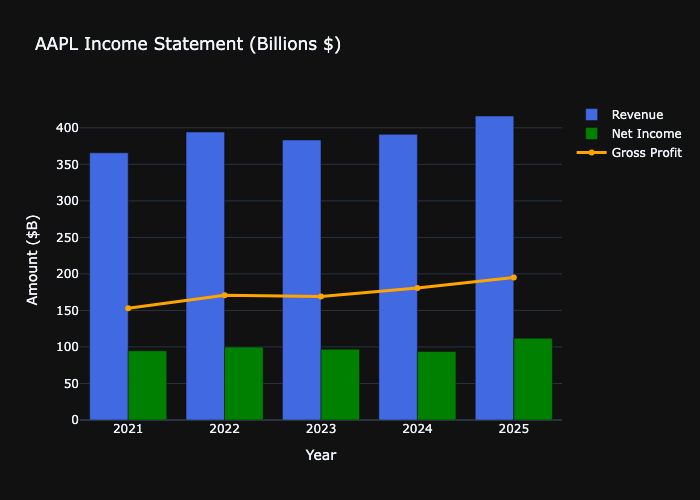


Growth Analysis:
  Revenue CAGR: 2.6%
  Net Income CAGR: 3.4%


In [11]:
# Fetch income statement (last 5 years)
response = qj.fmp.get_income_statement(symbol=symbol, period="annual", limit=5)
income_stmt = response.get('value', response) if isinstance(response, dict) else response

if income_stmt:
    df_income = pd.DataFrame(income_stmt)
    df_income['date'] = pd.to_datetime(df_income['date'])
    df_income = df_income.sort_values('date')
    
    # Plot revenue and net income
    fig = go.Figure()
    
    fig.add_trace(go.Bar(
        x=df_income['date'].dt.year,
        y=df_income['revenue'] / 1e9,
        name='Revenue',
        marker_color='royalblue'
    ))
    
    fig.add_trace(go.Bar(
        x=df_income['date'].dt.year,
        y=df_income['netIncome'] / 1e9,
        name='Net Income',
        marker_color='green'
    ))
    
    # Add gross profit line
    fig.add_trace(go.Scatter(
        x=df_income['date'].dt.year,
        y=df_income['grossProfit'] / 1e9,
        name='Gross Profit',
        mode='lines+markers',
        line=dict(color='orange', width=3)
    ))
    
    fig.update_layout(
        title=f'{symbol} Income Statement (Billions $)',
        xaxis_title='Year',
        yaxis_title='Amount ($B)',
        barmode='group',
        template='plotly_dark',
        height=500
    )
    fig.show()
    
    # Show growth rates
    print("\nGrowth Analysis:")
    revenue_growth = (df_income['revenue'].iloc[-1] / df_income['revenue'].iloc[0]) ** (1/len(df_income)) - 1
    income_growth = (df_income['netIncome'].iloc[-1] / df_income['netIncome'].iloc[0]) ** (1/len(df_income)) - 1
    print(f"  Revenue CAGR: {revenue_growth*100:.1f}%")
    print(f"  Net Income CAGR: {income_growth*100:.1f}%")


## 3. Profitability Margins

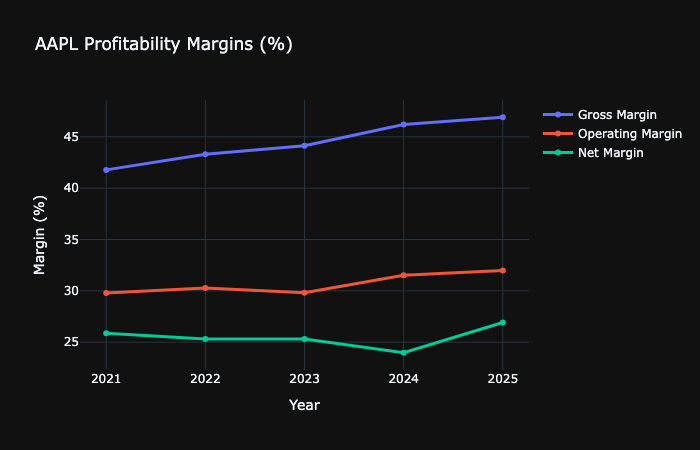


Latest Margins (2025):
  Gross:     46.9%
  Operating: 32.0%
  Net:       26.9%


In [12]:
if income_stmt:
    # Calculate margins
    df_income['grossMargin'] = df_income['grossProfit'] / df_income['revenue'] * 100
    df_income['operatingMargin'] = df_income['operatingIncome'] / df_income['revenue'] * 100
    df_income['netMargin'] = df_income['netIncome'] / df_income['revenue'] * 100
    
    # Plot margins
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(
        x=df_income['date'].dt.year,
        y=df_income['grossMargin'],
        name='Gross Margin',
        mode='lines+markers',
        line=dict(width=3)
    ))
    
    fig.add_trace(go.Scatter(
        x=df_income['date'].dt.year,
        y=df_income['operatingMargin'],
        name='Operating Margin',
        mode='lines+markers',
        line=dict(width=3)
    ))
    
    fig.add_trace(go.Scatter(
        x=df_income['date'].dt.year,
        y=df_income['netMargin'],
        name='Net Margin',
        mode='lines+markers',
        line=dict(width=3)
    ))
    
    fig.update_layout(
        title=f'{symbol} Profitability Margins (%)',
        xaxis_title='Year',
        yaxis_title='Margin (%)',
        template='plotly_dark',
        height=450
    )
    fig.show()
    
    # Latest margins
    latest = df_income.iloc[-1]
    print(f"\nLatest Margins ({int(latest['date'].year)}):")
    print(f"  Gross:     {latest['grossMargin']:.1f}%")
    print(f"  Operating: {latest['operatingMargin']:.1f}%")
    print(f"  Net:       {latest['netMargin']:.1f}%")


## 4. Balance Sheet Analysis

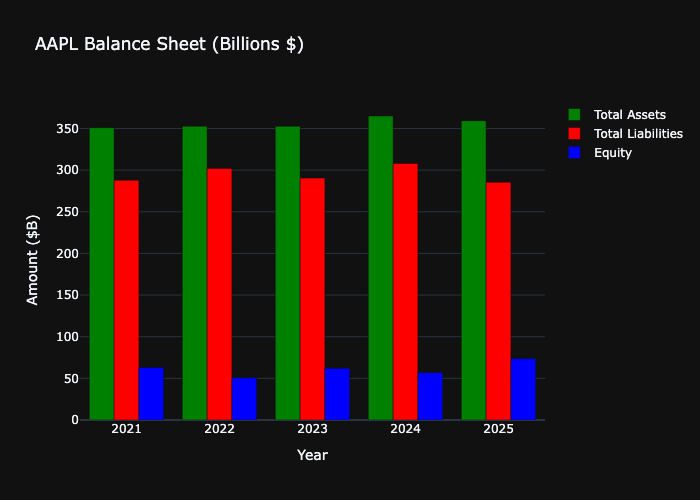


Financial Health (2025):
  Total Assets:    $359.2B
  Total Debt:      $112.4B
  Cash:            $33.5B
  Net Cash:        $-78.8B
  Debt/Equity:     1.52
  Current Ratio:   0.89


In [13]:
# Fetch balance sheet
response = qj.fmp.get_balance_sheet_statement(symbol=symbol, period="annual", limit=5)
balance_sheet = response.get('value', response) if isinstance(response, dict) else response

if balance_sheet:
    df_bs = pd.DataFrame(balance_sheet)
    df_bs['date'] = pd.to_datetime(df_bs['date'])
    df_bs = df_bs.sort_values('date')
    
    # Plot assets vs liabilities
    fig = go.Figure()
    
    fig.add_trace(go.Bar(
        x=df_bs['date'].dt.year,
        y=df_bs['totalAssets'] / 1e9,
        name='Total Assets',
        marker_color='green'
    ))
    
    fig.add_trace(go.Bar(
        x=df_bs['date'].dt.year,
        y=df_bs['totalLiabilities'] / 1e9,
        name='Total Liabilities',
        marker_color='red'
    ))
    
    fig.add_trace(go.Bar(
        x=df_bs['date'].dt.year,
        y=df_bs['totalStockholdersEquity'] / 1e9,
        name='Equity',
        marker_color='blue'
    ))
    
    fig.update_layout(
        title=f'{symbol} Balance Sheet (Billions $)',
        xaxis_title='Year',
        yaxis_title='Amount ($B)',
        barmode='group',
        template='plotly_dark',
        height=500
    )
    fig.show()
    
    # Financial health metrics
    latest = df_bs.iloc[-1]
    debt_equity = latest['totalDebt'] / latest['totalStockholdersEquity'] if latest['totalStockholdersEquity'] > 0 else 0
    current_ratio = latest['totalCurrentAssets'] / latest['totalCurrentLiabilities'] if latest['totalCurrentLiabilities'] > 0 else 0
    
    print(f"\nFinancial Health ({int(latest['date'].year)}):")
    print(f"  Total Assets:    ${latest['totalAssets']/1e9:.1f}B")
    print(f"  Total Debt:      ${latest['totalDebt']/1e9:.1f}B")
    print(f"  Cash:            ${latest['cashAndCashEquivalents']/1e9:.1f}B")
    print(f"  Net Cash:        ${(latest['cashAndCashEquivalents']-latest['totalDebt'])/1e9:.1f}B")
    print(f"  Debt/Equity:     {debt_equity:.2f}")
    print(f"  Current Ratio:   {current_ratio:.2f}")


## 5. Cash Flow Analysis

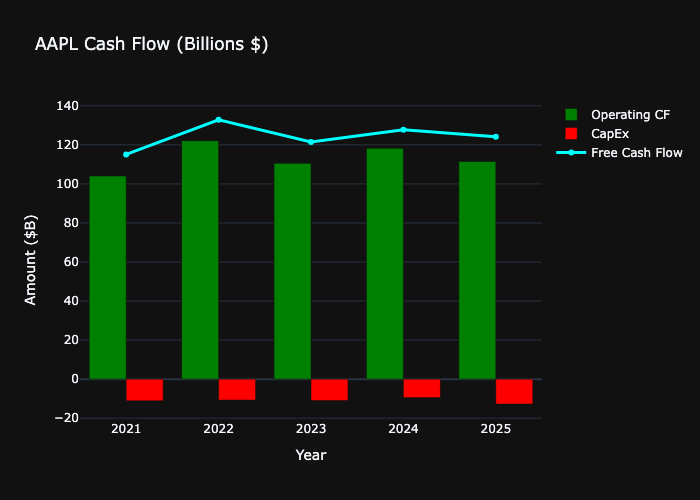


Cash Flow Summary (2025):
  Operating CF:    $111.5B
  CapEx:           $-12.7B
  Free Cash Flow:  $124.2B
  Dividends Paid:  $0.0B
  Buybacks:        $90.7B


In [14]:
# Fetch cash flow
response = qj.fmp.get_cash_flow_statement(symbol=symbol, period="annual", limit=5)
cash_flow = response.get('value', response) if isinstance(response, dict) else response

if cash_flow:
    df_cf = pd.DataFrame(cash_flow)
    df_cf['date'] = pd.to_datetime(df_cf['date'])
    df_cf = df_cf.sort_values('date')
    
    # Calculate Free Cash Flow
    df_cf['freeCashFlow'] = df_cf['operatingCashFlow'] - df_cf['capitalExpenditure']
    
    # Plot
    fig = go.Figure()
    
    fig.add_trace(go.Bar(
        x=df_cf['date'].dt.year,
        y=df_cf['operatingCashFlow'] / 1e9,
        name='Operating CF',
        marker_color='green'
    ))
    
    fig.add_trace(go.Bar(
        x=df_cf['date'].dt.year,
        y=df_cf['capitalExpenditure'] / 1e9,
        name='CapEx',
        marker_color='red'
    ))
    
    fig.add_trace(go.Scatter(
        x=df_cf['date'].dt.year,
        y=df_cf['freeCashFlow'] / 1e9,
        name='Free Cash Flow',
        mode='lines+markers',
        line=dict(color='cyan', width=3)
    ))
    
    fig.update_layout(
        title=f'{symbol} Cash Flow (Billions $)',
        xaxis_title='Year',
        yaxis_title='Amount ($B)',
        barmode='group',
        template='plotly_dark',
        height=500
    )
    fig.show()
    
    # Cash flow summary
    latest = df_cf.iloc[-1]
    print(f"\nCash Flow Summary ({int(latest['date'].year)}):")
    print(f"  Operating CF:    ${latest['operatingCashFlow']/1e9:.1f}B")
    print(f"  CapEx:           ${latest['capitalExpenditure']/1e9:.1f}B")
    print(f"  Free Cash Flow:  ${latest['freeCashFlow']/1e9:.1f}B")
    print(f"  Dividends Paid:  ${abs(latest.get('dividendsPaid', 0))/1e9:.1f}B")
    print(f"  Buybacks:        ${abs(latest.get('commonStockRepurchased', 0))/1e9:.1f}B")


## 6. Key Ratios

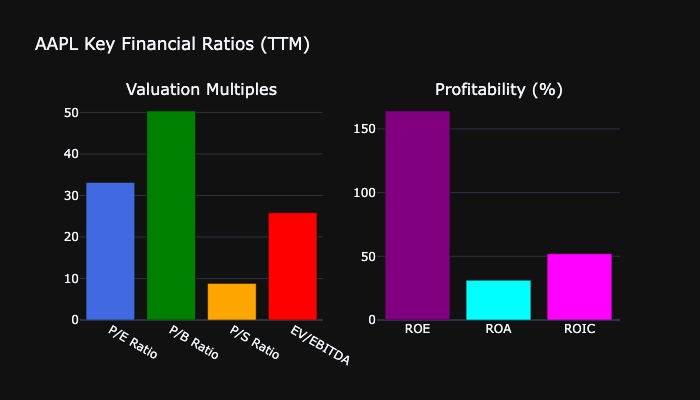


AAPL Key Ratios (TTM):

  Valuation:
    P/E Ratio: 33.14
    P/B Ratio: 50.35
    P/S Ratio: 8.82
    EV/EBITDA: 25.83

  Profitability:
    ROE: 164.0%
    ROA: 31.2%
    ROIC: 52.0%


In [23]:
# Fetch financial ratios (TTM) - for valuation multiples
response = qj.fmp.get_financial_ratios_ttm(symbol=symbol)
ratios = response.get('value', response) if isinstance(response, dict) else response

# Fetch key metrics (TTM) - for profitability
metrics_resp = qj.fmp.get_key_metrics_ttm(symbol=symbol)
metrics = metrics_resp.get('value', metrics_resp) if isinstance(metrics_resp, dict) else metrics_resp

if ratios and metrics:
    r = ratios[0] if isinstance(ratios, list) else ratios
    m = metrics[0] if isinstance(metrics, list) else metrics
    
    # Valuation from financial_ratios_ttm
    valuation = {
        'P/E Ratio': r.get('peRatioTTM', 0) or 0,
        'P/B Ratio': r.get('priceToBookRatioTTM', 0) or 0,
        'P/S Ratio': r.get('priceToSalesRatioTTM', 0) or 0,
        'EV/EBITDA': r.get('enterpriseValueMultipleTTM', 0) or 0
    }
    
    # Profitability from key_metrics_ttm
    profitability = {
        'ROE': (m.get('returnOnEquityTTM', 0) or 0) * 100,
        'ROA': (m.get('returnOnAssetsTTM', 0) or 0) * 100,
        'ROIC': (m.get('roicTTM', 0) or 0) * 100
    }
    
    # Create visualization
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=('Valuation Multiples', 'Profitability (%)'),
        specs=[[{'type': 'bar'}, {'type': 'bar'}]]
    )
    
    fig.add_trace(
        go.Bar(
            x=list(valuation.keys()),
            y=list(valuation.values()),
            marker_color=['royalblue', 'green', 'orange', 'red']
        ),
        row=1, col=1
    )
    
    fig.add_trace(
        go.Bar(
            x=list(profitability.keys()),
            y=list(profitability.values()),
            marker_color=['purple', 'cyan', 'magenta']
        ),
        row=1, col=2
    )
    
    fig.update_layout(
        title=f'{symbol} Key Financial Ratios (TTM)',
        template='plotly_dark',
        showlegend=False,
        height=400
    )
    fig.show()
    
    print(f"\n{symbol} Key Ratios (TTM):")
    print(f"\n  Valuation:")
    for k, v in valuation.items():
        print(f"    {k}: {v:.2f}")
    print(f"\n  Profitability:")
    for k, v in profitability.items():
        print(f"    {k}: {v:.1f}%")


## 7. Peer Comparison

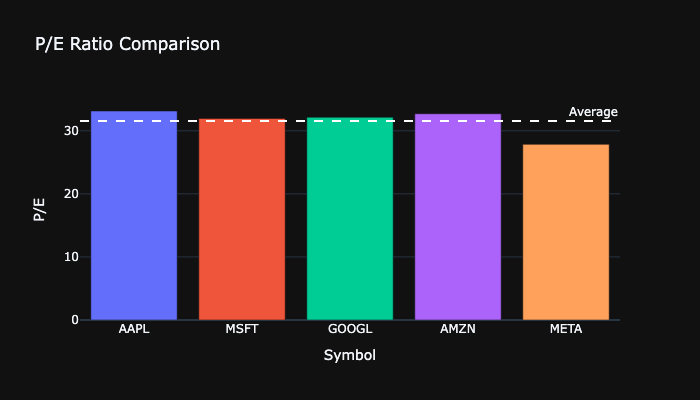

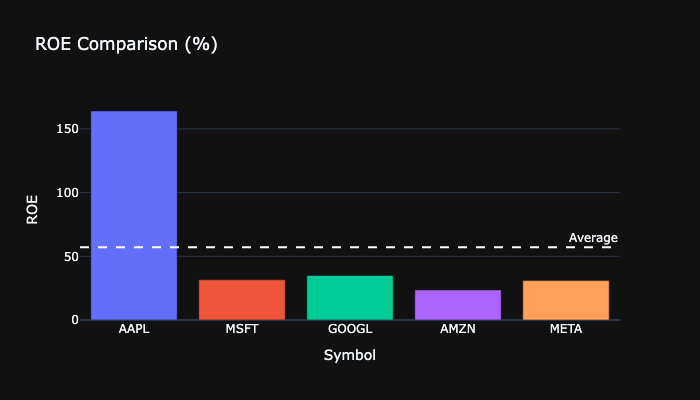


Peer Comparison Table:
Symbol       P/E       P/B        ROE  Div Yield
  AAPL 33.144005 50.350046 164.046910   0.414737
  MSFT 31.963204  9.235872  31.525436   0.753646
 GOOGL 32.151906 10.326304  34.996979   0.251104
  AMZN 32.705018  6.767141  23.619352   0.000000
  META 27.851365  8.399641  30.934379   0.324259


In [25]:
# Compare with peers
peers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META"]

comparison_data = []
for peer in peers:
    try:
        # Get financial ratios for P/E, P/B, Div Yield
        response = qj.fmp.get_financial_ratios_ttm(symbol=peer)
        ratios = response.get('value', response) if isinstance(response, dict) else response
        
        # Get key metrics for ROE
        metrics_resp = qj.fmp.get_key_metrics_ttm(symbol=peer)
        metrics = metrics_resp.get('value', metrics_resp) if isinstance(metrics_resp, dict) else metrics_resp
        
        if ratios and metrics:
            r = ratios[0] if isinstance(ratios, list) else ratios
            m = metrics[0] if isinstance(metrics, list) else metrics
            comparison_data.append({
                'Symbol': peer,
                'P/E': r.get('peRatioTTM', 0) or 0,
                'P/B': r.get('priceToBookRatioTTM', 0) or 0,
                'ROE': (m.get('returnOnEquityTTM', 0) or 0) * 100,
                'Div Yield': (r.get('dividendYieldTTM', 0) or 0) * 100
            })
    except:
        pass

if comparison_data:
    df_comp = pd.DataFrame(comparison_data)
    
    # P/E comparison
    fig = px.bar(
        df_comp,
        x='Symbol',
        y='P/E',
        color='Symbol',
        title='P/E Ratio Comparison',
        template='plotly_dark'
    )
    fig.add_hline(y=df_comp['P/E'].mean(), line_dash='dash', 
                  annotation_text='Average', line_color='white')
    fig.update_layout(height=400, showlegend=False)
    fig.show()
    
    # ROE comparison
    fig = px.bar(
        df_comp,
        x='Symbol',
        y='ROE',
        color='Symbol',
        title='ROE Comparison (%)',
        template='plotly_dark'
    )
    fig.add_hline(y=df_comp['ROE'].mean(), line_dash='dash', 
                  annotation_text='Average', line_color='white')
    fig.update_layout(height=400, showlegend=False)
    fig.show()
    
    print("\nPeer Comparison Table:")
    print(df_comp.to_string(index=False))


## 8. Valuation Summary

In [29]:
# Final summary
if profile and ratios and income_stmt:
    p = profile[0] if isinstance(profile, list) else profile
    r = ratios[0] if isinstance(ratios, list) else ratios
    latest_income = df_income.iloc[-1]
    
    mkt_cap = p.get('mktCap', 0)
    revenue = latest_income['revenue']
    net_income = latest_income['netIncome']
    
    print("="*60)
    print(f"FUNDAMENTAL SUMMARY - {symbol}")
    print("="*60)
    
    print(f"\nCOMPANY")
    print(f"   {p.get('companyName', symbol)}")
    print(f"   Sector: {p.get('sector', 'N/A')}")
    
    print(f"\nVALUATION")
    print(f"   Market Cap:  ${mkt_cap/1e12:.2f}T")
    print(f"   P/E Ratio:   {r.get('peRatioTTM', 0):.1f}x")
    print(f"   P/B Ratio:   {r.get('pbRatioTTM', 0):.1f}x")
    print(f"   EV/EBITDA:   {r.get('enterpriseValueOverEBITDATTM', 0):.1f}x")
    
    print(f"\nFINANCIALS (Latest Annual)")
    print(f"   Revenue:     ${revenue/1e9:.1f}B")
    print(f"   Net Income:  ${net_income/1e9:.1f}B")
    print(f"   Net Margin:  {net_income/revenue*100:.1f}%")
    
    print(f"\nRETURNS")
    print(f"   ROE:         {r.get('roeTTM', 0)*100:.1f}%")
    print(f"   ROA:         {r.get('roaTTM', 0)*100:.1f}%")
    print(f"   Div Yield:   {r.get('dividendYieldTTM', 0)*100:.2f}%")
    
    print("\n" + "="*60)


FUNDAMENTAL SUMMARY - AAPL

COMPANY
   Apple Inc.
   Sector: Technology

VALUATION
   Market Cap:  $0.00T
   P/E Ratio:   27.9x
   P/B Ratio:   0.0x
   EV/EBITDA:   0.0x

FINANCIALS (Latest Annual)
   Revenue:     $416.2B
   Net Income:  $112.0B
   Net Margin:  26.9%

RETURNS
   ROE:         0.0%
   ROA:         0.0%
   Div Yield:   0.32%



## Summary

Fundamental analysis covered:
- **Company Profile**: Basic info, market cap, sector
- **Income Statement**: Revenue, margins, growth
- **Balance Sheet**: Assets, liabilities, financial health
- **Cash Flow**: Operating CF, CapEx, Free Cash Flow
- **Ratios**: Valuation (P/E, P/B), Profitability (ROE, ROA)
- **Peer Comparison**: Benchmarking against competitors